In [14]:

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import LabelEncoder

# ── 1. Load Dataset 
url = "../datasets/Titanic-Dataset.csv"
df = pd.read_csv(url)

print("=== Titanic Dataset ===")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# ── 2. Preprocessing ─────────────────────────────────────────

# Drop columns not useful for prediction
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)          # Median age
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # Most frequent port

# Encode categorical variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])           # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked']) # C=0, Q=1, S=2

print("\n=== Preprocessed Data ===")
print(df.head())
print(f"\nMissing Values After Preprocessing:\n{df.isnull().sum()}")

# ── 3. Feature / Target Split ────────────────────────────────
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ── 4. Train XGBoost Model ───────────────────────────────────
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ── 5. Evaluate ──────────────────────────────────────────────
y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print("\n=== Model Evaluation ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))


=== Titanic Dataset ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

C:\Users\alikh\AppData\Local\Temp\ipykernel_8004\798307340.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)          # Median age
C:\Users\alikh\AppData\Local\Temp\ipykernel_8004\798307340.py:24: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

=== Iris Dataset ===
Classes : ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Samples : 150

=== Performance vs Number of Estimators ===
  Estimators |  Accuracy |  Precision |  Recall
--------------------------------------------------
           1 |    0.6667 |     0.5000 |  0.6667
           5 |    0.9333 |     0.9333 |  0.9333
          10 |    0.9333 |     0.9333 |  0.9333
          50 |    0.9333 |     0.9333 |  0.9333
         100 |    0.9333 |     0.9333 |  0.9333
         200 |    0.9333 |     0.9333 |  0.9333


C:\Users\alikh\AppData\Local\Temp\ipykernel_8004\960058002.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('Set1', 3)


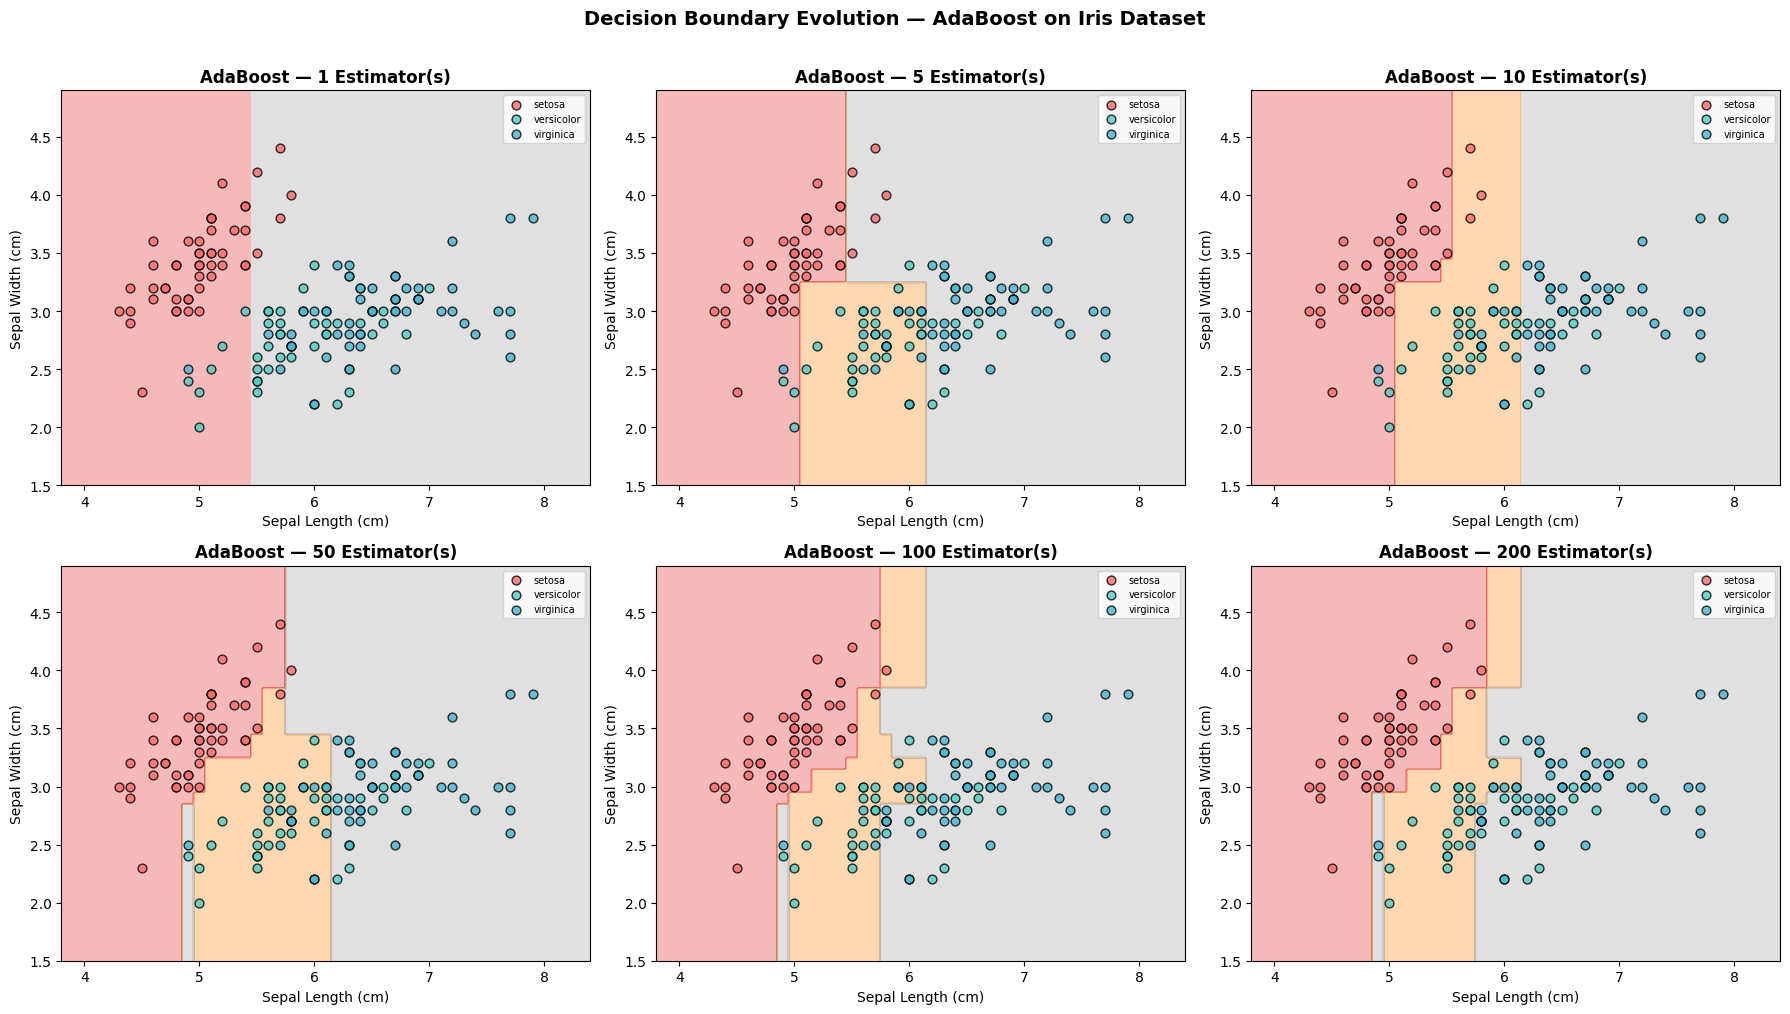


Decision boundary plot saved.


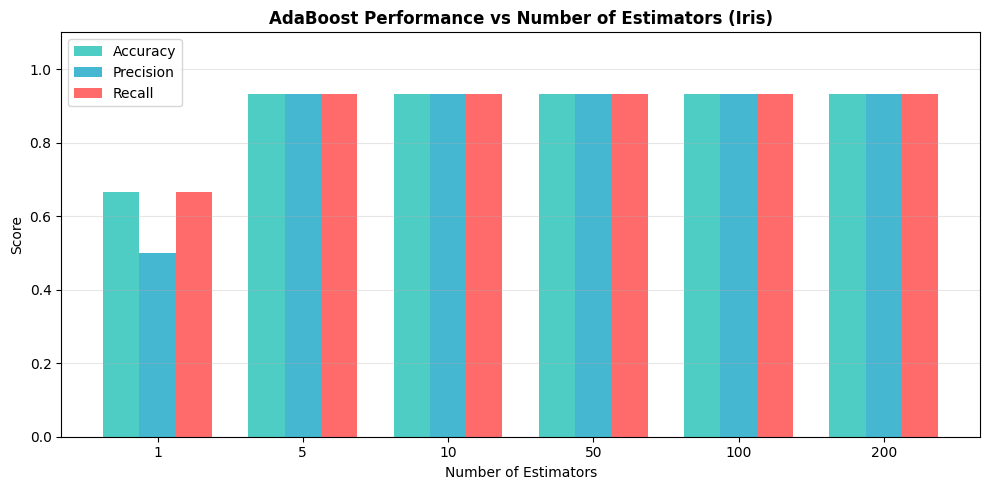

Metrics comparison plot saved.

=== Best Model (n_estimators=5) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [15]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import label_binarize

# ── 1. Load Dataset ──────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

# Use only 2 features for 2D decision boundary visualization
X_2d = X[:, :2]  # sepal length & sepal width

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_2d, X_test_2d, _, _ = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Iris Dataset ===")
print(f"Classes : {iris.target_names}")
print(f"Features: {iris.feature_names}")
print(f"Samples : {X.shape[0]}")

# ── 2. Compare Different Number of Estimators ────────────────
estimator_counts = [1, 5, 10, 50, 100, 200]
results = []

print("\n=== Performance vs Number of Estimators ===")
print(f"{'Estimators':>12} | {'Accuracy':>9} | {'Precision':>10} | {'Recall':>7}")
print("-" * 50)

for n in estimator_counts:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    results.append((n, acc, prec, rec))
    print(f"{n:>12} | {acc:>9.4f} | {prec:>10.4f} | {rec:>7.4f}")

# ── 3. Decision Boundary Visualization ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cmap   = plt.cm.get_cmap('Set1', 3)

for i, n in enumerate(estimator_counts):
    clf_2d = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        random_state=42
    )
    clf_2d.fit(X_train_2d, y_train)

    # Create mesh grid
    h = 0.02
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax = axes[i]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    for cls, color in zip(range(3), colors):
        mask = y == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=iris.target_names[cls],
                   edgecolors='k', s=40, alpha=0.8)

    ax.set_title(f'AdaBoost — {n} Estimator(s)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sepal Length (cm)')
    ax.set_ylabel('Sepal Width (cm)')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Decision Boundary Evolution — AdaBoost on Iris Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('/home/claude/task2_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDecision boundary plot saved.")

# ── 4. Performance Metrics Bar Chart ─────────────────────────
ns, accs, precs, recs = zip(*results)

x = np.arange(len(ns))
width = 0.25

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(x - width, accs,  width, label='Accuracy',  color='#4ECDC4')
ax2.bar(x,         precs, width, label='Precision', color='#45B7D1')
ax2.bar(x + width, recs,  width, label='Recall',    color='#FF6B6B')

ax2.set_xlabel('Number of Estimators')
ax2.set_ylabel('Score')
ax2.set_title('AdaBoost Performance vs Number of Estimators (Iris)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(ns)
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('/home/claude/task2_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Metrics comparison plot saved.")

# ── 5. Final Model Report ────────────────────────────────────
best_n = max(results, key=lambda x: x[1])[0]
clf_best = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=best_n,
    random_state=42
)
clf_best.fit(X_train, y_train)
y_pred_best = clf_best.predict(X_test)

print(f"\n=== Best Model (n_estimators={best_n}) ===")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))


=== California Housing Dataset ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape  : (20640, 9)
Target : MedHouseVal (median house value in $100,000s)

Missing: 0 values

=== Hyperparameter Experiment ===
 Max Depth |  Learning Rate |     RMSE |  R² Score
-------------------------------------------------------
         3 |           0.01 |   0.7084 |    0.6170
         3 |           0.10 |   0.5117 |    0.8002
 

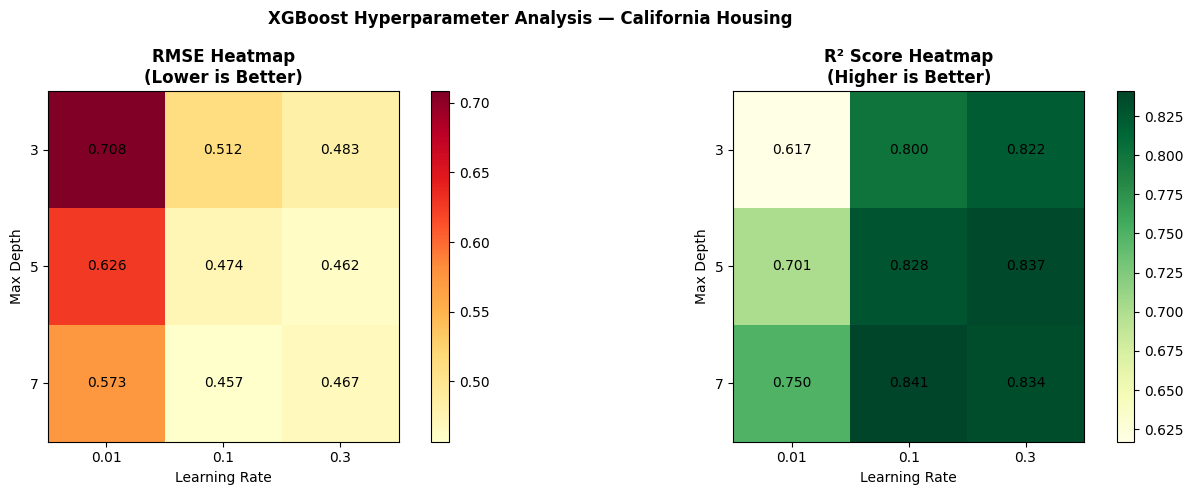


Heatmap saved.

=== Best Config: depth=7, lr=0.1 ===
RMSE: 0.4566 | R²: 0.8409


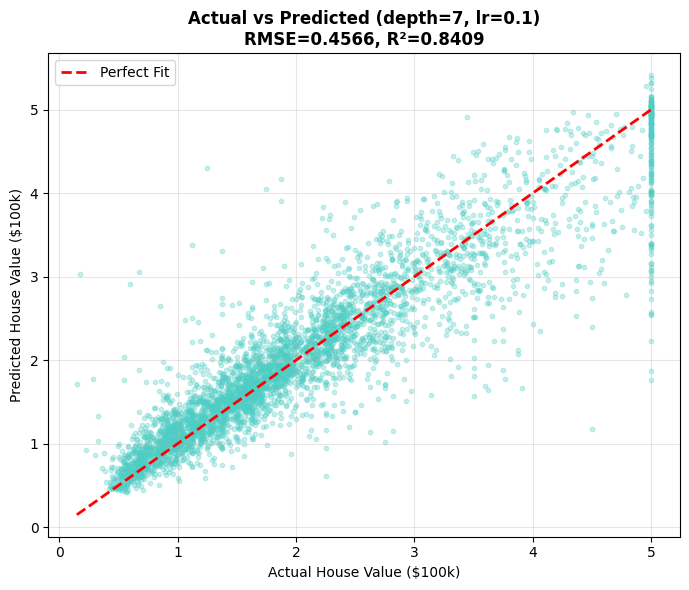

Actual vs Predicted plot saved.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import itertools

# ── 1. Load Dataset ──────────────────────────────────────────
housing = fetch_california_housing()
X, y    = housing.data, housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y

print("=== California Housing Dataset ===")
print(df.head())
print(f"\nShape  : {df.shape}")
print(f"Target : MedHouseVal (median house value in $100,000s)")
print(f"\nMissing: {df.isnull().sum().sum()} values")

# ── 2. Split & Scale ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── 3. Hyperparameter Experiment ─────────────────────────────
max_depths     = [3, 5, 7]
learning_rates = [0.01, 0.1, 0.3]

results = []
print("\n=== Hyperparameter Experiment ===")
print(f"{'Max Depth':>10} | {'Learning Rate':>14} | {'RMSE':>8} | {'R² Score':>9}")
print("-" * 55)

for depth, lr in itertools.product(max_depths, learning_rates):
    model = XGBRegressor(
        n_estimators=200,
        max_depth=depth,
        learning_rate=lr,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results.append((depth, lr, rmse, r2))
    print(f"{depth:>10} | {lr:>14.2f} | {rmse:>8.4f} | {r2:>9.4f}")

# ── 4. Visualization — RMSE Heatmap ──────────────────────────
rmse_matrix = np.zeros((len(max_depths), len(learning_rates)))
r2_matrix   = np.zeros((len(max_depths), len(learning_rates)))

for d, depth in enumerate(max_depths):
    for l, lr in enumerate(learning_rates):
        for row in results:
            if row[0] == depth and row[1] == lr:
                rmse_matrix[d][l] = row[2]
                r2_matrix[d][l]   = row[3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(rmse_matrix, cmap='YlOrRd')
ax1.set_xticks(range(len(learning_rates)))
ax1.set_yticks(range(len(max_depths)))
ax1.set_xticklabels([str(lr) for lr in learning_rates])
ax1.set_yticklabels([str(d) for d in max_depths])
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Max Depth')
ax1.set_title('RMSE Heatmap\n(Lower is Better)', fontweight='bold')
plt.colorbar(im1, ax=ax1)
for i in range(len(max_depths)):
    for j in range(len(learning_rates)):
        ax1.text(j, i, f"{rmse_matrix[i, j]:.3f}", ha='center', va='center', fontsize=10)

im2 = ax2.imshow(r2_matrix, cmap='YlGn')
ax2.set_xticks(range(len(learning_rates)))
ax2.set_yticks(range(len(max_depths)))
ax2.set_xticklabels([str(lr) for lr in learning_rates])
ax2.set_yticklabels([str(d) for d in max_depths])
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Max Depth')
ax2.set_title('R² Score Heatmap\n(Higher is Better)', fontweight='bold')
plt.colorbar(im2, ax=ax2)
for i in range(len(max_depths)):
    for j in range(len(learning_rates)):
        ax2.text(j, i, f"{r2_matrix[i, j]:.3f}", ha='center', va='center', fontsize=10)

plt.suptitle('XGBoost Hyperparameter Analysis — California Housing', fontweight='bold')
plt.tight_layout()
# plt.savefig('/home/claude/task3_hyperparameter_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nHeatmap saved.")

# ── 5. Best Model — Actual vs Predicted ──────────────────────
best = min(results, key=lambda x: x[2])
print(f"\n=== Best Config: depth={best[0]}, lr={best[1]} ===")
print(f"RMSE: {best[2]:.4f} | R²: {best[3]:.4f}")

best_model = XGBRegressor(
    n_estimators=200,
    max_depth=best[0],
    learning_rate=best[1],
    random_state=42,
    verbosity=0
)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

fig2, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#4ECDC4')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
ax.set_xlabel('Actual House Value ($100k)')
ax.set_ylabel('Predicted House Value ($100k)')
ax.set_title(f'Actual vs Predicted (depth={best[0]}, lr={best[1]})\nRMSE={best[2]:.4f}, R²={best[3]:.4f}',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('/home/claude/task3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Actual vs Predicted plot saved.")


=== Bank Marketing Dataset ===
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

Shape: (4521, 17)

Target Distribution:
y
no     4000
yes     521
Name: count, 

C:\Users\alikh\AppData\Local\Temp\ipykernel_8004\1300539324.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_enc.select_dtypes(include='object').columns



=== Without Sample Weights ===
ROC-AUC: 0.8754
              precision    recall  f1-score   support

          No       0.91      0.97      0.94       801
         Yes       0.47      0.24      0.32       104

    accuracy                           0.88       905
   macro avg       0.69      0.60      0.63       905
weighted avg       0.86      0.88      0.86       905


=== With Sample Weights ===
ROC-AUC: 0.8773
              precision    recall  f1-score   support

          No       0.97      0.82      0.89       801
         Yes       0.36      0.78      0.49       104

    accuracy                           0.82       905
   macro avg       0.66      0.80      0.69       905
weighted avg       0.90      0.82      0.84       905



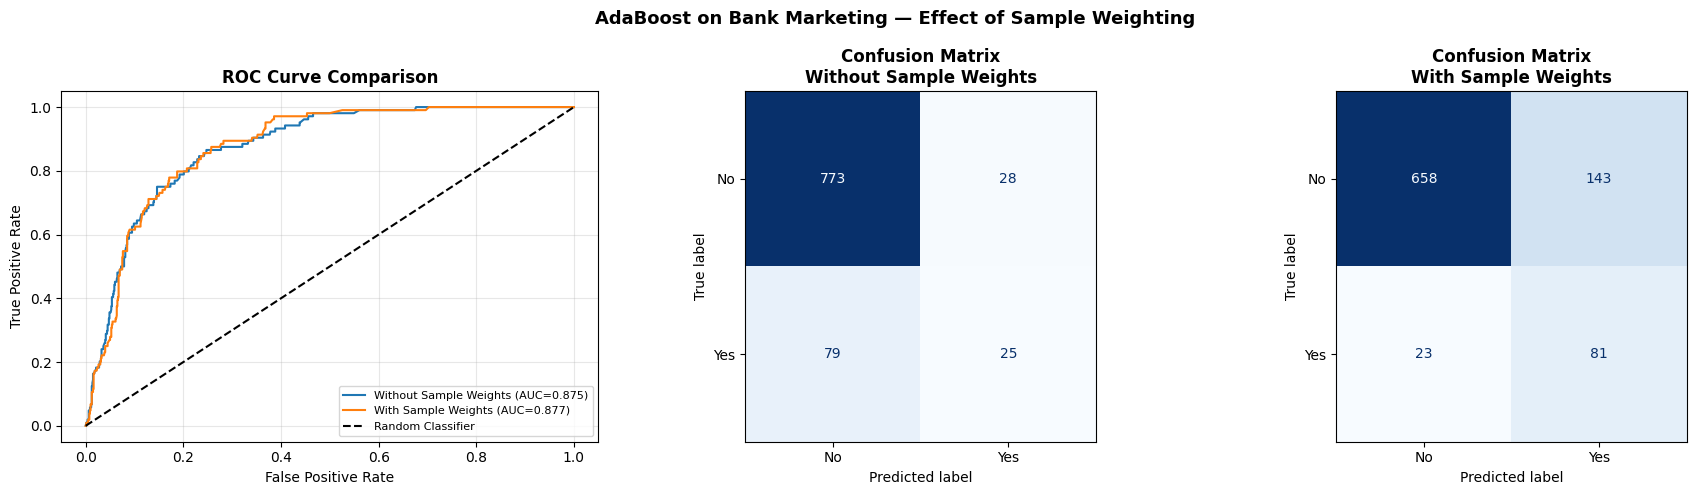


ROC & Confusion Matrix plot saved.


In [11]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import urllib.request

# ── 1. Load Dataset ──────────────────────────────────────────
# Bank Marketing dataset from UCI (semicolon-separated)
url = "../datasets/bank.csv"

df = pd.read_csv(url, sep=';')


print("=== Bank Marketing Dataset ===")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nTarget Distribution:\n{df['y'].value_counts()}")
print(f"\nClass Imbalance Ratio: {df['y'].value_counts()['no'] / df['y'].value_counts()['yes']:.2f}:1")

# ── 2. Preprocessing ─────────────────────────────────────────
df_enc = df.copy()

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_enc.select_dtypes(include='object').columns
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop(columns=['y'])
y = df_enc['y']  # 0=no, 1=yes

print(f"\nFeatures: {list(X.columns)}")
print(f"Encoded target — 0: no, 1: yes")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Handle Imbalance via Sample Weights ───────────────────
# Compute per-sample weights: minority class gets higher weight
class_counts = y_train.value_counts()
n_total = len(y_train)
class_weight = {cls: n_total / (2 * count) for cls, count in class_counts.items()}
sample_weights = y_train.map(class_weight).values

print(f"\nClass weights: {class_weight}")

# ── 4. Train Two Models (without vs with sample weighting) ───
models = {
    'Without Sample Weights': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, random_state=42
    ),
    'With Sample Weights': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, random_state=42
    )
}

fit_args = {
    'Without Sample Weights': {},
    'With Sample Weights': {'sample_weight': sample_weights}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

roc_ax = axes[0]
all_results = {}

for name, model in models.items():
    model.fit(X_train, y_train, **fit_args[name])
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    roc_auc     = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    all_results[name] = {
        'y_pred': y_pred, 'roc_auc': roc_auc,
        'fpr': fpr, 'tpr': tpr
    }
    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

# ── 5. ROC Curves ────────────────────────────────────────────
for name, res in all_results.items():
    roc_ax.plot(res['fpr'], res['tpr'],
                label=f"{name} (AUC={res['roc_auc']:.3f})")

roc_ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('ROC Curve Comparison', fontweight='bold')
roc_ax.legend(fontsize=8)
roc_ax.grid(alpha=0.3)

# ── 6. Confusion Matrices ────────────────────────────────────
for ax, (name, res) in zip(axes[1:], all_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')

plt.suptitle('AdaBoost on Bank Marketing — Effect of Sample Weighting',
             fontweight='bold', fontsize=13)
plt.tight_layout()
# plt.savefig('/home/claude/task4_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nROC & Confusion Matrix plot saved.")


=== Heart Disease Dataset (Cleveland) ===
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Shape: (303, 14)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target Distribution:
target
0    160
1    137
Name: count, dtype: int6

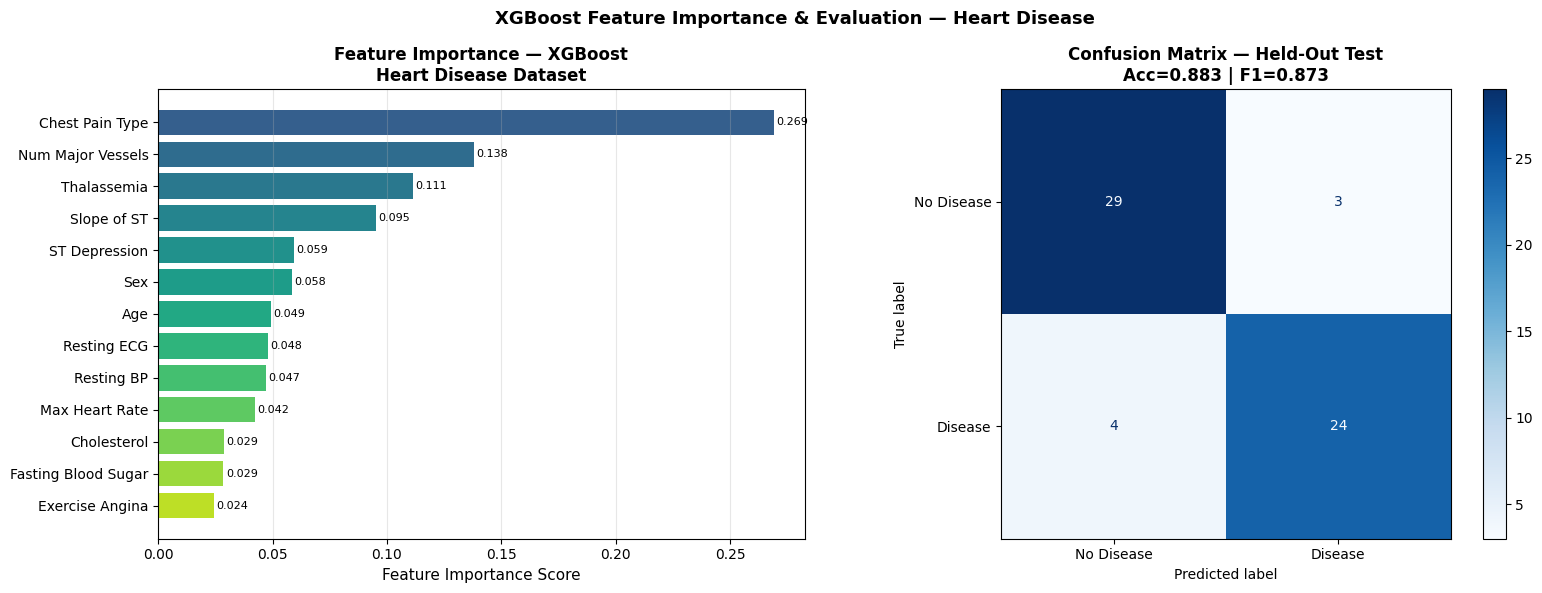


Feature importance & confusion matrix plot saved.

=== Top 5 Most Important Features ===
  1. Chest Pain Type     : 0.2690
  2. Num Major Vessels   : 0.1381
  3. Thalassemia         : 0.1112
  4. Slope of ST         : 0.0952
  5. ST Depression       : 0.0592


In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

# ── 1. Load Dataset ──────────────────────────────────────────
# UCI Heart Disease dataset (Cleveland)
url = ("../datasets/heart.csv")

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=columns, na_values='?')

print("=== Heart Disease Dataset (Cleveland) ===")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# ── 2. Preprocessing ─────────────────────────────────────────
# Drop rows with missing values (only 6 rows)
df.dropna(inplace=True)

# Binarize target: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

print(f"\nTarget Distribution:\n{df['target'].value_counts()}")
print(f"Classes — 0: No Disease, 1: Disease")

X = df.drop(columns=['target'])
y = df['target']

feature_names = list(X.columns)

# ── 3. Train / Validation / Test Split ───────────────────────
# 60% train | 20% val | 20% held-out test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ── 4. Train XGBoost Model ───────────────────────────────────
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# ── 5. Held-Out Test Evaluation ──────────────────────────────
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n=== Held-Out Test Set Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['No Disease', 'Disease']))

# ── 6. Feature Importance Analysis ───────────────────────────
importances = model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
sorted_feats = [feature_names[i] for i in sorted_idx]
sorted_imps  = importances[sorted_idx]

# Human-readable feature descriptions
feat_desc = {
    'age': 'Age', 'sex': 'Sex', 'cp': 'Chest Pain Type',
    'trestbps': 'Resting BP', 'chol': 'Cholesterol', 'fbs': 'Fasting Blood Sugar',
    'restecg': 'Resting ECG', 'thalach': 'Max Heart Rate',
    'exang': 'Exercise Angina', 'oldpeak': 'ST Depression',
    'slope': 'Slope of ST', 'ca': 'Num Major Vessels', 'thal': 'Thalassemia'
}
sorted_labels = [feat_desc.get(f, f) for f in sorted_feats]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(sorted_feats)))
bars = ax1.barh(sorted_labels[::-1], sorted_imps[::-1], color=colors[::-1])
ax1.set_xlabel('Feature Importance Score', fontsize=11)
ax1.set_title('Feature Importance — XGBoost\nHeart Disease Dataset', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for bar, imp in zip(bars, sorted_imps[::-1]):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{imp:.3f}', va='center', fontsize=8)

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Disease'])
disp.plot(ax=ax2, colorbar=True, cmap='Blues')
ax2.set_title(f'Confusion Matrix — Held-Out Test\nAcc={acc:.3f} | F1={f1:.3f}',
              fontweight='bold')

plt.suptitle('XGBoost Feature Importance & Evaluation — Heart Disease',
             fontweight='bold', fontsize=13)
plt.tight_layout()
# plt.savefig('/home/claude/task5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFeature importance & confusion matrix plot saved.")

# ── 7. Top Features Summary ──────────────────────────────────
print("\n=== Top 5 Most Important Features ===")
for rank, (feat, imp) in enumerate(zip(sorted_feats[:5], sorted_imps[:5]), 1):
    print(f"  {rank}. {feat_desc.get(feat, feat):20s}: {imp:.4f}")
